# Gabarito — Polígonos

Este notebook traz a resolução comentada dos exercícios de [`0411a_poligonos.ipynb`](0411a_poligonos.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo
import math
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Arc, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal (0408a): zero se O, P e Q são colineares, positiva se o
    caminho O → P → Q vira para a esquerda e negativa se vira para a direita."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def segmentos_se_cruzam(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 se cruzam formando um "X": as pontas de cada um ficam em
    lados opostos da reta do outro (0408a)."""
    return (orientacao(P1, P2, Q1) * orientacao(P1, P2, Q2) < 0
            and orientacao(Q1, Q2, P1) * orientacao(Q1, Q2, P2) < 0)


LETRAS = "ABCDEFGHIJKLMNOPQRST"


def desenhar_poligono(ax, vertices, cor: str = COR_PONTO, largura: float = 2.5, estilo: str = "-",
                      preencher: bool = True, fechado: bool = True) -> None:
    """Desenha os lados do polígono (na ordem dos vértices) e pinta levemente o interior.
    Com `fechado=False`, desenha só a linha poligonal aberta (sem o lado que volta ao primeiro vértice)."""
    if preencher:
        ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.15, edgecolor="none"))
    n = len(vertices)
    for k in range(n if fechado else n - 1):
        ax.plot(*zip(vertices[k], vertices[(k + 1) % n]), color=cor, lw=largura, linestyle=estilo,
                solid_capstyle="round")


def sao_consecutivos(i: int, j: int, n: int) -> bool:
    """True se os vértices de índices i e j de um polígono de n vértices são vizinhos no contorno
    (o último vértice é vizinho do primeiro)."""
    return (j - i) % n in (1, n - 1)


def poligono_regular(n: int, raio: float = 1.0, centro=(0.0, 0.0), giro: float = 90.0) -> list[np.ndarray]:
    """Vértices (em sentido anti-horário) de um polígono regular de n lados, espalhados igualmente sobre
    uma circunferência. Serve só para DESENHAR: a teoria dos polígonos regulares fica para 0418a."""
    c = np.asarray(centro, dtype=float)
    return [c + raio * direcao(giro + 360 * k / n) for k in range(n)]


def segmentos_se_encontram(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 têm algum ponto em comum: cruzando em "X" ou só encostando
    (uma ponta de um sobre o outro)."""
    def na_caixa(X, P, Q) -> bool:
        return (min(P[0], Q[0]) - 1e-9 <= X[0] <= max(P[0], Q[0]) + 1e-9
                and min(P[1], Q[1]) - 1e-9 <= X[1] <= max(P[1], Q[1]) + 1e-9)

    if segmentos_se_cruzam(P1, P2, Q1, Q2):
        return True
    # Encostar: uma ponta de um segmento é colinear com o outro e fica entre as pontas dele
    casos = ((Q1, P1, P2), (Q2, P1, P2), (P1, Q1, Q2), (P2, Q1, Q2))
    return any(math.isclose(orientacao(P, Q, X), 0, abs_tol=1e-9) and na_caixa(X, P, Q) for X, P, Q in casos)


def eh_simples(vertices) -> bool:
    """True se os vértices, ligados em ordem, formam um polígono simples: três vértices consecutivos
    nunca alinhados e nenhum par de lados não consecutivos se tocando."""
    n = len(vertices)
    if n < 3:
        return False
    if any(math.isclose(orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % n]), 0, abs_tol=1e-9)
           for k in range(n)):
        return False
    for i, j in combinations(range(n), 2):  # o lado i vai do vértice i ao vértice i + 1
        if sao_consecutivos(i, j, n):
            continue  # lados vizinhos se encontram no vértice comum, e isso é permitido
        if segmentos_se_encontram(vertices[i], vertices[(i + 1) % n], vertices[j], vertices[(j + 1) % n]):
            return False
    return True


NOMES_POLIGONOS = {
    3: "triângulo", 4: "quadrilátero", 5: "pentágono", 6: "hexágono", 7: "heptágono", 8: "octógono",
    9: "eneágono", 10: "decágono", 11: "undecágono", 12: "dodecágono", 20: "icoságono",
}


def nome_poligono(n: int) -> str:
    """Nome do polígono de n lados (ou 'polígono de n lados', quando não há nome na tabela).

    Raises:
        ValueError: se n < 3 (não existe polígono com menos de 3 lados).
    """
    if n < 3:
        raise ValueError("um polígono tem pelo menos 3 lados")
    return NOMES_POLIGONOS.get(n, f"polígono de {n} lados")


def num_diagonais(n: int) -> int:
    """Número de diagonais de um polígono convexo de n lados: d = n(n − 3)/2."""
    return n * (n - 3) // 2


def diagonais_do_poligono(vertices) -> list[tuple[int, int]]:
    """Lista os pares (i, j) de índices de vértices NÃO consecutivos: as diagonais, por força bruta."""
    n = len(vertices)
    pares = []
    for i in range(n):  # primeiro vértice do par
        for j in range(i + 1, n):  # segundo vértice (j > i, para não contar o mesmo par duas vezes)
            if not sao_consecutivos(i, j, n):
                pares.append((i, j))
    return pares


def contar_diagonais_forca_bruta(vertices) -> int:
    """Conta as diagonais do polígono testando todos os pares de vértices."""
    return len(diagonais_do_poligono(vertices))


def caminho_da_tartaruga(comandos, inicio=(0.0, 0.0), rumo: float = 0.0) -> tuple[list[np.ndarray], float]:
    """Simula a tartaruga: cada comando (avanco, virada) faz ela andar `avanco` para a frente e, em
    seguida, virar `virada` graus para a esquerda (negativo = para a direita).
    Devolve a lista dos pontos por onde ela passou e o total de graus que ela virou."""
    posicao = np.array(inicio, dtype=float)
    pontos = [posicao]
    total_virado = 0.0
    for avanco, virada in comandos:
        posicao = posicao + avanco * direcao(rumo)
        pontos.append(posicao)
        rumo += virada
        total_virado += virada
    return pontos, total_virado

## Básico

**Exercício 1.** Diagonais dos polígonos de 5, 8, 15 e 20 lados; soma dos ângulos internos dos de 7, 9 e 12 lados, e os seus nomes.

In [2]:
# (a) d = n(n − 3)/2: de cada vértice saem n − 3 diagonais, e cada diagonal é contada duas vezes
#     (uma a partir de cada ponta). A divisão inteira // dá um int, e é exata: n(n − 3) é sempre par.
diagonais_ex1 = {n: n * (n - 3) // 2 for n in (5, 8, 15, 20)}
# 5·2/2 = 5;   8·5/2 = 20;   15·12/2 = 90;   20·17/2 = 170 (os apertos de mão da mesa de 20 pessoas!)

# (b) S_i = (n − 2)·180°: as diagonais de um vértice dividem o polígono em n − 2 triângulos.
somas_ex1 = {n: (n - 2) * 180 for n in (7, 9, 12)}
# 5·180° = 900°;   7·180° = 1260°;   10·180° = 1800°

# (c) Os nomes vêm da tabela da seção 2.
nomes_ex1 = [nome_poligono(n) for n in (7, 9, 12)]

print(f"diagonais: {diagonais_ex1}")
print(f"somas dos ângulos internos: {somas_ex1}")
print(f"nomes: {nomes_ex1}")

diagonais: {5: 5, 8: 20, 15: 90, 20: 170}
somas dos ângulos internos: {7: 900, 9: 1260, 12: 1800}
nomes: ['heptágono', 'eneágono', 'dodecágono']


**Exercício 2.** Um ângulo interno e um ângulo externo do hexágono, do octógono e do decágono regulares.

In [3]:
angulos_ex2 = {}
for n in (6, 8, 10):
    interno = (n - 2) * 180 / n  # a soma dos internos dividida igualmente entre os n vértices
    externo = 360 / n  # a volta completa da tartaruga dividida em n viradas iguais
    angulos_ex2[n] = (interno, externo)

# Em cada vértice, interno + externo formam um ângulo raso: confere nos três casos.
suplementares_ex2 = all(math.isclose(interno + externo, 180) for interno, externo in angulos_ex2.values())

display(pd.DataFrame([
    {"polígono regular": nome_poligono(n), "interno (n − 2)·180°/n": f"{i:g}°", "externo 360°/n": f"{e:g}°",
     "interno + externo": f"{i + e:g}°"}
    for n, (i, e) in angulos_ex2.items()
]).style.hide(axis="index"))
print(f"suplementares nos três casos? {suplementares_ex2}")
# Um atalho: calcule primeiro o externo (360/n, a conta mais fácil) e depois o interno = 180° − externo.
# Hexágono: 60° e 120°;  octógono: 45° e 135°;  decágono: 36° e 144°.

polígono regular,interno (n − 2)·180°/n,externo 360°/n,interno + externo
hexágono,120°,60°,180°
octógono,135°,45°,180°
decágono,144°,36°,180°


suplementares nos três casos? True


## Intermediário

**Exercício 3.** As funções das fórmulas e a que descobre o número de lados de um polígono regular pelo ângulo externo.

In [4]:
def num_diagonais_ex3(n: int) -> int:
    """d = n(n − 3)/2. Entre n e n − 3, um é par e o outro é ímpar, então n(n − 3) é sempre par
    e a divisão inteira // é exata (e devolve um int)."""
    return n * (n - 3) // 2


def soma_internos_ex3(n: int) -> float:
    """S_i = (n − 2)·180°: n − 2 triângulos de 180°."""
    return (n - 2) * 180


def soma_externos_ex3(n: int) -> float:
    """S_e = 360°, qualquer que seja n: uma volta completa da tartaruga."""
    return 360


def lados_pelo_externo_ex3(angulo: float) -> int | None:
    """n = 360°/a_e, desde que dê um inteiro maior ou igual a 3; senão, None."""
    if angulo <= 0:
        return None
    candidato = 360 / angulo  # pode dar 50.00000000000001 em vez de 50 (arredondamento do float)
    n = round(candidato)
    if n < 3 or not math.isclose(candidato, n):
        return None
    return n


# Conferências do enunciado: valores conhecidos e força bruta
for n in (3, 4, 6):
    print(f"{nome_poligono(n):>12}: d = {num_diagonais_ex3(n)},  S_i = {soma_internos_ex3(n)}°,  "
          f"S_e = {soma_externos_ex3(n)}°")
bate = all(num_diagonais_ex3(n) == contar_diagonais_forca_bruta(poligono_regular(n)) for n in range(3, 31))
print(f"\nfórmula = força bruta para n de 3 a 30? {bate}\n")
for angulo in [120, 90, 60, 30, 18, 24, 7.2, 1, 50, 25, 7, 150, 180, 200]:
    print(f"ângulo externo de {angulo:>5}°  ->  360/{angulo} = {360 / angulo:.6g}  ->  n = {lados_pelo_externo_ex3(angulo)}")
# 150° e 180° falham por outro motivo: 360/150 = 2,4 e 360/180 = 2, menos de 3 lados.

   triângulo: d = 0,  S_i = 180°,  S_e = 360°
quadrilátero: d = 2,  S_i = 360°,  S_e = 360°
    hexágono: d = 9,  S_i = 720°,  S_e = 360°

fórmula = força bruta para n de 3 a 30? True

ângulo externo de   120°  ->  360/120 = 3  ->  n = 3
ângulo externo de    90°  ->  360/90 = 4  ->  n = 4
ângulo externo de    60°  ->  360/60 = 6  ->  n = 6
ângulo externo de    30°  ->  360/30 = 12  ->  n = 12
ângulo externo de    18°  ->  360/18 = 20  ->  n = 20
ângulo externo de    24°  ->  360/24 = 15  ->  n = 15
ângulo externo de   7.2°  ->  360/7.2 = 50  ->  n = 50
ângulo externo de     1°  ->  360/1 = 360  ->  n = 360
ângulo externo de    50°  ->  360/50 = 7.2  ->  n = None
ângulo externo de    25°  ->  360/25 = 14.4  ->  n = None
ângulo externo de     7°  ->  360/7 = 51.4286  ->  n = None
ângulo externo de   150°  ->  360/150 = 2.4  ->  n = None
ângulo externo de   180°  ->  360/180 = 2  ->  n = None
ângulo externo de   200°  ->  360/200 = 1.8  ->  n = None


**Exercício 4.** O número de lados a partir de 35 diagonais, de $S_i = 1980^\circ$ e de um ângulo externo de 18°.

In [5]:
# (a) Por código: varrer n até encontrar n(n − 3)/2 = 35.
n_a_ex4 = next(n for n in range(3, 101) if n * (n - 3) // 2 == 35)

#     Por álgebra: n(n − 3)/2 = 35  ->  n² − 3n = 70  ->  n² − 3n − 70 = 0.
#     Bhaskara com a = 1, b = −3, c = −70:  Δ = 9 + 280 = 289,  √Δ = 17,  n = (3 ± 17)/2.
a, b, c = 1, -3, -70
delta = b**2 - 4 * a * c
raizes_ex4 = sorted([(-b - math.sqrt(delta)) / (2 * a), (-b + math.sqrt(delta)) / (2 * a)])
#     As raízes são −7 e 10. A equação não "sabe" que n conta lados; a raiz negativa é descartada,
#     porque um polígono não pode ter −7 lados. Resposta: decágono (10 lados).

# (b) (n − 2)·180 = 1980  ->  n − 2 = 11  ->  n = 13.
n_b_ex4 = 1980 // 180 + 2

# (c) No regular, a_e = 360°/n  ->  n = 360/18 = 20 (um icoságono).
n_c_ex4 = 360 // 18

print(f"(a) n = {n_a_ex4}  (raízes de n² − 3n − 70 = 0: {raizes_ex4})")
print(f"(b) n = {n_b_ex4}  ({nome_poligono(n_b_ex4)})")
print(f"(c) n = {n_c_ex4}  ({nome_poligono(n_c_ex4)})")
# Antes de dividir, vale conferir se a conta "fecha": 1980 é múltiplo de 180? Sim (11·180).
# Se a soma fosse 2000°, não existiria polígono: 2000/180 não é inteiro.

(a) n = 10  (raízes de n² − 3n − 70 = 0: [-7.0, 10.0])
(b) n = 13  (polígono de 13 lados)
(c) n = 20  (icoságono)


## Desafio

**Exercício 5.** O número de triangulações de um polígono convexo de $n$ lados, por força bruta, para $n$ de 3 a 8.

In [6]:
def triangulacoes(n: int) -> list[tuple[tuple[int, int], ...]]:
    """Todas as triangulações do polígono convexo de n lados: as escolhas de n − 3 diagonais
    em que nenhum par se cruza."""
    vertices = poligono_regular(n)
    lista = diagonais_do_poligono(vertices)
    validas = []
    for escolha in combinations(lista, n - 3):
        cruzou = any(
            segmentos_se_cruzam(vertices[i1], vertices[j1], vertices[i2], vertices[j2])
            for (i1, j1), (i2, j2) in combinations(escolha, 2)
        )
        if not cruzou:
            validas.append(escolha)
    return validas


triangulacoes_ex5 = [len(triangulacoes(n)) for n in range(3, 9)]
razao_ex5 = [triangulacoes_ex5[k] / triangulacoes_ex5[k - 1] for k in range(1, 6)]

for n, total in zip(range(3, 9), triangulacoes_ex5):
    escolhas = math.comb(num_diagonais(n), n - 3)
    print(f"n = {n}: {escolhas:>6} escolhas de {n - 3} diagonais testadas  ->  {total:>3} triangulações")
print(f"\nsequência: {triangulacoes_ex5}")
print(f"razões: {[round(r, 4) for r in razao_ex5]}  (não é constante: cresce devagar, rumo a 4)")

n = 3:      1 escolhas de 0 diagonais testadas  ->    1 triangulações
n = 4:      2 escolhas de 1 diagonais testadas  ->    2 triangulações
n = 5:     10 escolhas de 2 diagonais testadas  ->    5 triangulações
n = 6:     84 escolhas de 3 diagonais testadas  ->   14 triangulações
n = 7:   1001 escolhas de 4 diagonais testadas  ->   42 triangulações
n = 8:  15504 escolhas de 5 diagonais testadas  ->  132 triangulações

sequência: [1, 2, 5, 14, 42, 132]
razões: [2.0, 2.5, 2.8, 3.0, 3.1429]  (não é constante: cresce devagar, rumo a 4)


As 14 triangulações do hexágono, desenhadas. Repare que só **6** delas são "leques" saindo de um vértice (uma para cada vértice); as outras 8 combinam diagonais que saem de vértices diferentes, e algumas formam um triângulo "no meio" do hexágono.

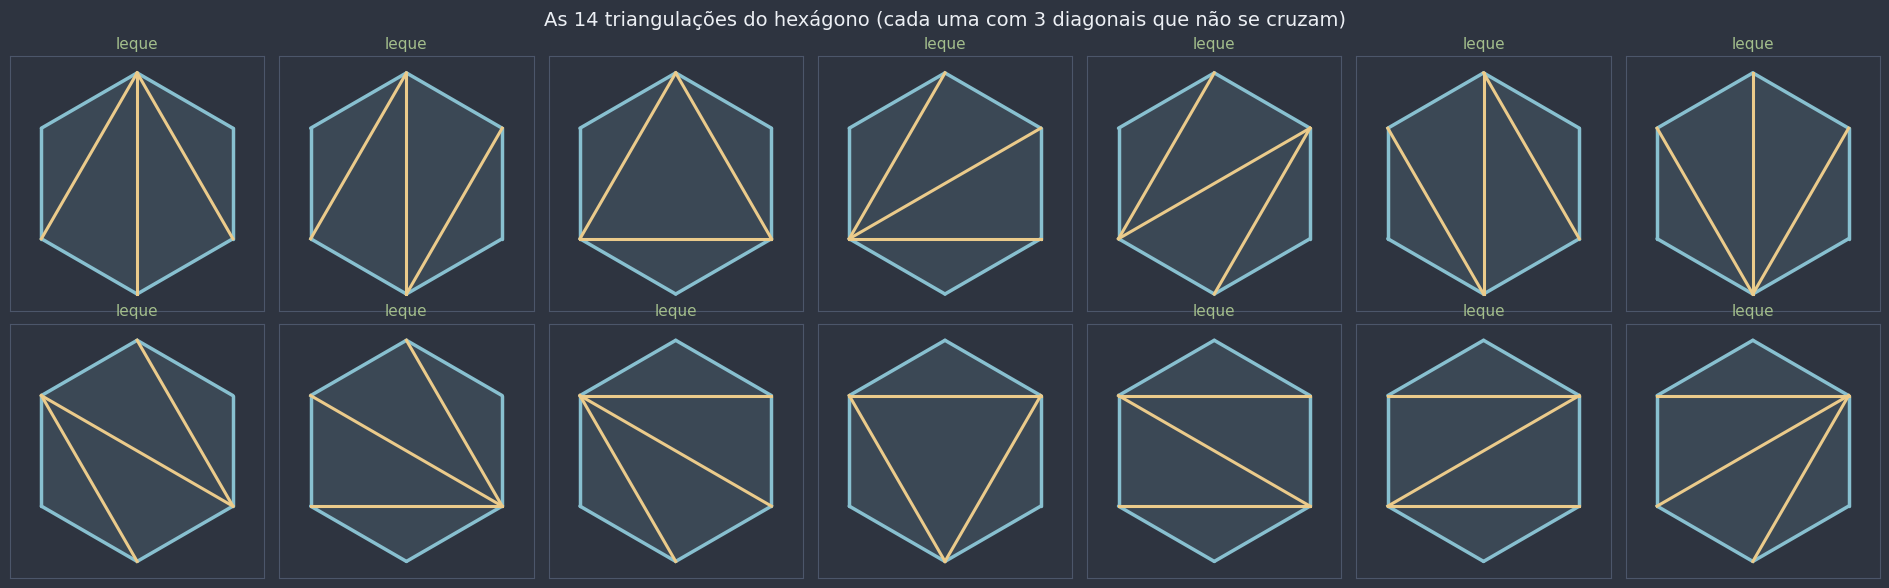

In [7]:
todas = triangulacoes(6)
hexagono = poligono_regular(6)
fig, eixos = plt.subplots(2, 7, figsize=(19, 6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, escolha in zip(eixos.flat, todas):
    preparar_eixo(ax, [(-1, -1), (1, 1)], margem=0.15)
    desenhar_poligono(ax, hexagono, cor=COR_PONTO, largura=2.5)
    for i, j in escolha:
        ax.plot(*zip(hexagono[i], hexagono[j]), color=COR_AVISO, lw=2.2)
    leque = len({v for par in escolha for v in par}) == 4  # as 3 diagonais têm um vértice em comum
    ax.set_title("leque" if leque else "", color=COR_DESTAQUE, fontsize=11)
fig.suptitle("As 14 triangulações do hexágono (cada uma com 3 diagonais que não se cruzam)", color=NORD_TEXTO,
             fontsize=14)
plt.tight_layout()
plt.show()

**A sequência 1, 2, 5, 14, 42, 132, ...** é a dos **números de Catalan**, uma das sequências mais famosas da matemática. O matemático Leonhard Euler já contava triangulações de polígonos no século XVIII; os números ganharam o nome do belga Eugène Catalan, que os estudou no século XIX. Eles aparecem em lugares que, à primeira vista, não têm nada a ver com polígonos: o número de maneiras de colocar parênteses numa expressão como $a \cdot b \cdot c \cdot d$, o número de sequências de parênteses "bem fechadas" (como `(())()`), o número de caminhos numa grade que não cruzam a diagonal...

Existe uma fórmula fechada para eles, que você vai entender em 📌 Análise Combinatória:

$$C_k = \frac{1}{k + 1}\binom{2k}{k}, \qquad \text{e um polígono de } n \text{ lados tem } C_{n-2} \text{ triangulações.}$$

Repare também no custo da força bruta: para $n = 8$, o programa testou mais de 15 mil escolhas para achar 132 triangulações. Para $n = 20$ seriam bilhões de escolhas; na prática, os números de Catalan são calculados por fórmulas ou por recorrência, nunca testando todas as possibilidades.

📖 **Leitura complementar:** [Números de Catalan](https://pt.wikipedia.org/wiki/N%C3%BAmeros_de_Catalan)

In [8]:
# Conferindo a fórmula fechada com a força bruta
catalan = [math.comb(2 * k, k) // (k + 1) for k in range(1, 7)]
print(f"C_1 a C_6 pela fórmula: {catalan}")
print(f"força bruta (n = 3 a 8): {triangulacoes_ex5}")
print(f"iguais? {catalan == triangulacoes_ex5}")

C_1 a C_6 pela fórmula: [1, 2, 5, 14, 42, 132]
força bruta (n = 3 a 8): [1, 2, 5, 14, 42, 132]
iguais? True


**Exercício 6.** O pentagrama desenhado pela tartaruga: a virada em cada ponta, o total virado, o ângulo de cada ponta e a soma das pontas.

fechou? True;  total virado = 720° = 2 voltas
cada ponta: 36°;  soma das 5 pontas: 180°
o pentagrama é um polígono simples? False


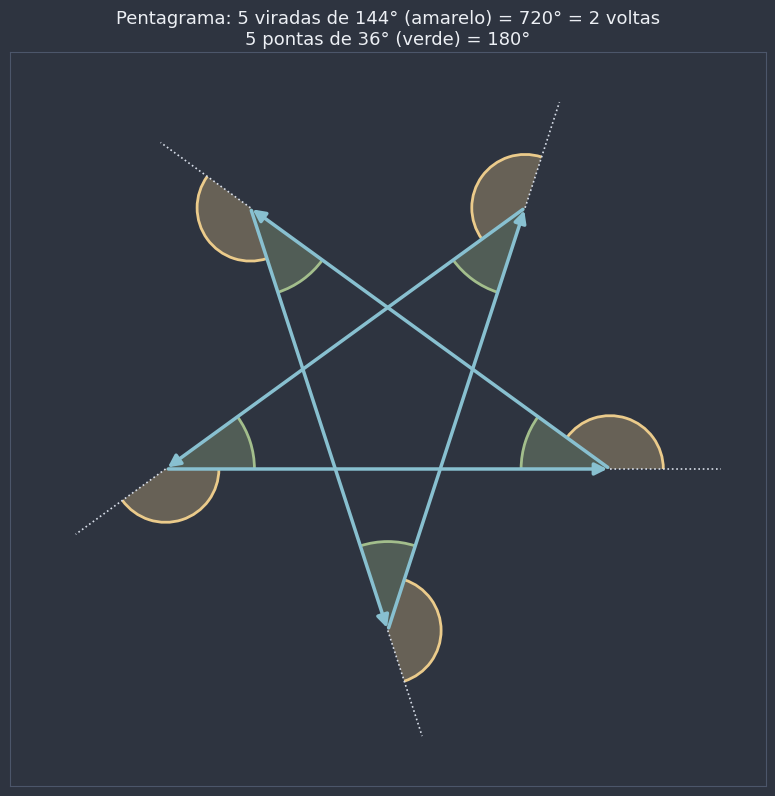

In [9]:
# (a) 5 viradas iguais que somam DUAS voltas: 5·X = 2·360°  ->  X = 144°.
virada_ex6 = 2 * 360 / 5

# (b) Os 5 comandos: avance 1, vire 144° para a esquerda.
comandos_ex6 = [(1.0, virada_ex6)] * 5
pontos_ex6, total_virado_ex6 = caminho_da_tartaruga(comandos_ex6)
print(f"fechou? {np.allclose(pontos_ex6[-1], pontos_ex6[0])};  total virado = {total_virado_ex6:g}° "
      f"= {total_virado_ex6 / 360:g} voltas")

# (c) Em cada ponta, a direção em que a tartaruga chega e a nova direção formam a ponta da estrela;
#     ponta + virada = 180° (suplementares), como o interno e o externo de um polígono.
ponta_ex6 = 180 - virada_ex6  # 36°
soma_pontas_ex6 = 5 * ponta_ex6  # 180°
print(f"cada ponta: {ponta_ex6:g}°;  soma das 5 pontas: {soma_pontas_ex6:g}°")

# (d) Os lados não vizinhos da estrela se cruzam: não é um polígono simples, e por isso a "regra dos
#     360°" (que vale para polígonos convexos) não se aplica. A tartaruga gira 720°, não 360°.
simples_ex6 = eh_simples(pontos_ex6[:-1])
print(f"o pentagrama é um polígono simples? {simples_ex6}")

# O desenho, com as viradas e as pontas
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, pontos_ex6, margem=0.35)
for k in range(5):
    P, Q = pontos_ex6[k], pontos_ex6[k + 1]
    ax.annotate("", xy=Q, xytext=P, arrowprops={"arrowstyle": "-|>", "color": COR_PONTO, "lw": 2.5,
                                                 "mutation_scale": 18})
    rumo_chegada = k * virada_ex6  # direção em que a tartaruga chega à ponta Q
    ax.plot(*zip(Q, Q + 0.25 * direcao(rumo_chegada)), color=NORD_TEXTO_SEC, lw=1.2, linestyle=":")
    desenhar_setor(ax, Q, rumo_chegada, virada_ex6, raio=0.12, cor=COR_AVISO, marcar_reto=False)
    desenhar_setor(ax, Q, rumo_chegada + virada_ex6, ponta_ex6, raio=0.2, cor=COR_DESTAQUE, marcar_reto=False)
ax.set_title(f"Pentagrama: 5 viradas de {virada_ex6:g}° (amarelo) = {total_virado_ex6:g}° = 2 voltas\n"
             f"5 pontas de {ponta_ex6:g}° (verde) = {soma_pontas_ex6:g}°", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

**Uma outra maneira de ver os 180° das pontas.** Num polígono convexo, a tartaruga dá **uma** volta e cada ângulo interno é $180^\circ$ menos a virada; somando, $S_i = n \cdot 180^\circ - 360^\circ$. No pentagrama, ela dá **duas** voltas, então a soma das pontas é

$$5 \cdot 180^\circ - 2 \cdot 360^\circ = 900^\circ - 720^\circ = 180^\circ.$$

A mesma conta vale para outras estrelas: uma estrela de $n$ pontas desenhada pulando vértices, em que a tartaruga dá $k$ voltas, tem pontas somando $n \cdot 180^\circ - k \cdot 360^\circ$. Experimente com `caminho_da_tartaruga([(1, 360 * 3 / 7)] * 7)`: uma estrela de 7 pontas em que a tartaruga dá 3 voltas.

📖 **Leitura complementar:** [Pentagrama](https://pt.wikipedia.org/wiki/Pentagrama)